First 5 Rows
   season                 team1                        team2        date  \
0    2023   Chennai Super Kings               Gujarat Titans  2023/03/31   
1    2023          Punjab Kings        Kolkata Knight Riders  2023/04/01   
2    2023  Lucknow Super Giants               Delhi Capitals  2023/04/01   
3    2023      Rajasthan Royals          Sunrisers Hyderabad  2023/04/02   
4    2023        Mumbai Indians  Royal Challengers Bangalore  2023/04/02   

   match_number                                              venue  \
0             1                              Narendra Modi Stadium   
1             2       Punjab Cricket Association IS Bindra Stadium   
2             3  Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...   
3             4                 Rajiv Gandhi International Stadium   
4             5                              M Chinnaswamy Stadium   

         city                  toss_winner toss_decision player_of_match  \
0   Ahmedabad               Gujar

C:\Users\Admin\AppData\Local\Temp\ipykernel_5332\1495975083.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="winner", data=df, order=df["winner"].value_counts().index, palette="viridis")


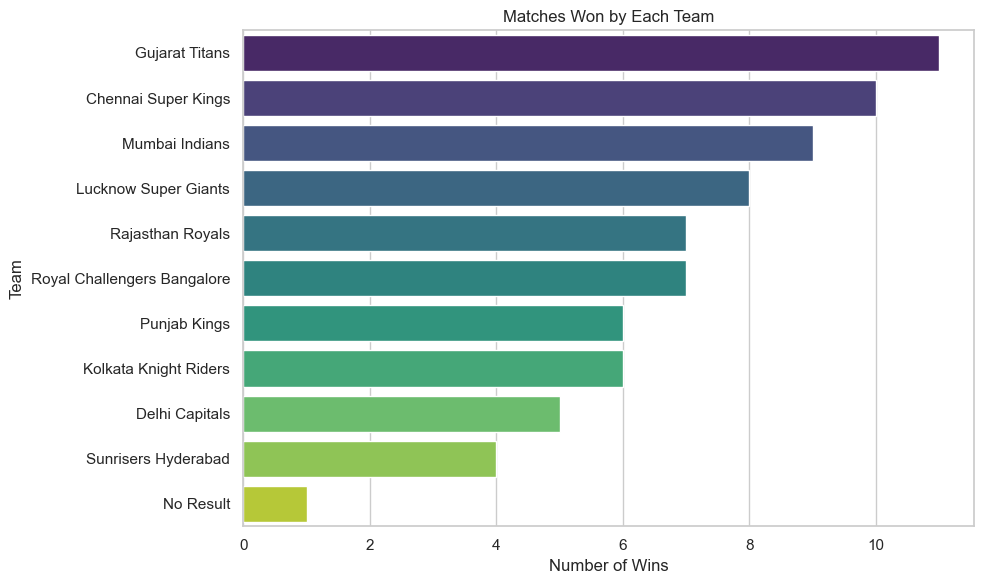

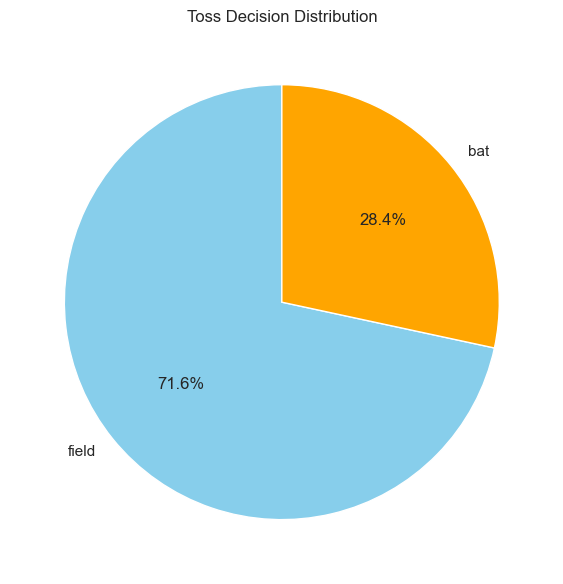

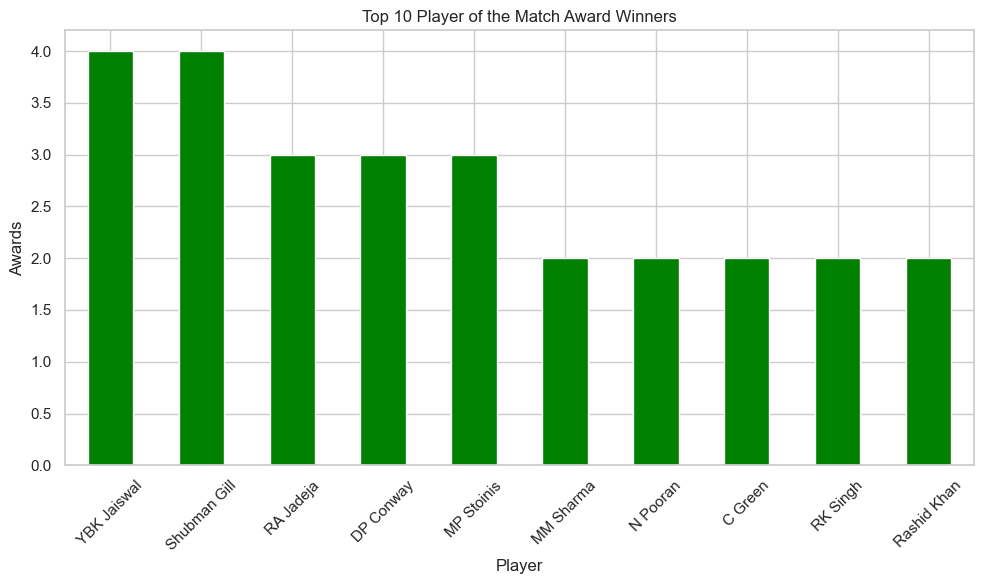

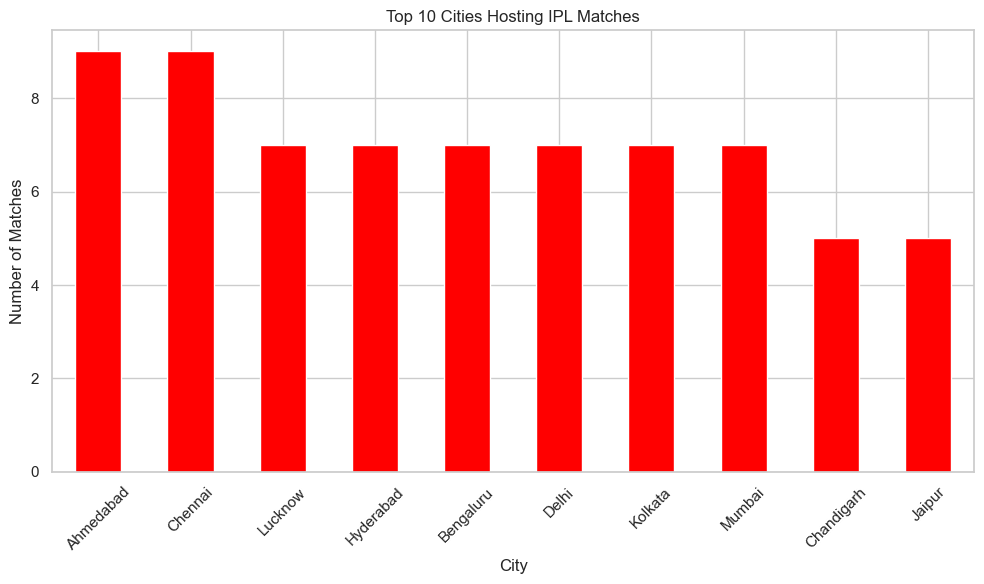


Top Teams by Wins
winner
Gujarat Titans                 11
Chennai Super Kings            10
Mumbai Indians                  9
Lucknow Super Giants            8
Rajasthan Royals                7
Royal Challengers Bangalore     7
Punjab Kings                    6
Kolkata Knight Riders           6
Delhi Capitals                  5
Sunrisers Hyderabad             4
Name: count, dtype: int64

Top Players of the Match
player_of_match
YBK Jaiswal     4
Shubman Gill    4
RA Jadeja       3
DP Conway       3
MP Stoinis      3
MM Sharma       2
N Pooran        2
C Green         2
RK Singh        2
Rashid Khan     2
Name: count, dtype: int64

Top Venues
venue
Narendra Modi Stadium                                           9
MA Chidambaram Stadium                                          9
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium    7
Rajiv Gandhi International Stadium                              7
M Chinnaswamy Stadium                                           7
Arun Jaitley

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

df = pd.read_csv(r"C:\Users\Admin\Downloads\archive (1)\matches.csv")

print("First 5 Rows")
print(df.head())

print("\nShape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(0)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["winner_runs"] = pd.to_numeric(df["winner_runs"], errors="coerce").fillna(0)
df["winner_wickets"] = pd.to_numeric(df["winner_wickets"], errors="coerce").fillna(0)

print("\nDescriptive Statistics")
print(df.describe())

print("\nCategorical Statistics")
print(df.describe(include="object"))

print("\nTotal Matches:", len(df))
print("Number of Seasons:", df["season"].nunique())
print("Number of Teams:", pd.concat([df["team1"], df["team2"]]).nunique())

print("\nMatches Won By Teams")
print(df["winner"].value_counts())

print("\nTop 10 Player of the Match")
print(df["player_of_match"].value_counts().head(10))

print("\nTop 10 Venues")
print(df["venue"].value_counts().head(10))

print("\nTop 10 Cities")
print(df["city"].value_counts().head(10))

print("\nToss Decisions")
print(df["toss_decision"].value_counts())

plt.figure(figsize=(10,6))
sns.countplot(y="winner", data=df, order=df["winner"].value_counts().index, palette="viridis")
plt.title("Matches Won by Each Team")
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
df["toss_decision"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue", "orange"]
)
plt.ylabel("")
plt.title("Toss Decision Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
df["player_of_match"].value_counts().head(10).plot(
    kind="bar",
    color="green"
)
plt.title("Top 10 Player of the Match Award Winners")
plt.xlabel("Player")
plt.ylabel("Awards")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
df["city"].value_counts().head(10).plot(
    kind="bar",
    color="red"
)
plt.title("Top 10 Cities Hosting IPL Matches")
plt.xlabel("City")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTop Teams by Wins")
print(df["winner"].value_counts().head(10))

print("\nTop Players of the Match")
print(df["player_of_match"].value_counts().head(10))

print("\nTop Venues")
print(df["venue"].value_counts().head(10))

df.to_csv("Cleaned_IPL_Matches.csv", index=False)

print("\nAnalysis Completed Successfully")
print("Cleaned dataset saved as Cleaned_IPL_Matches.csv")